In [2]:
#Michelle Ojeda-Tania Bermudez-Armando Robledo
print("Instalando librerías necesarias...")
print("Esto tomará unos 30 segundos...")

!pip install streamlit plotly polars -q

print("¡Instalación completada!")
print("Librerías instaladas:")
print("   - NumPy ✓")
print("   - Pandas ✓")
print("   - Matplotlib ✓")
print("   - Seaborn ✓")
print("   - Scikit-learn ✓")
print("   - Streamlit ✓")
print("   - Plotly ✓")
print("   - Polars ✓")
print("\n¡Todo listo! Continúa con la siguiente celda")

Instalando librerías necesarias...
Esto tomará unos 30 segundos...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.2 MB/s eta 0:00:00
¡Instalación completada!
Librerías instaladas:
   - NumPy ✓
   - Pandas ✓
   - Matplotlib ✓
   - Seaborn ✓
   - Scikit-learn ✓
   - Streamlit ✓
   - Plotly ✓
   - Polars ✓

¡Todo listo! Continúa con la siguiente celda


In [4]:
print("Importando librerías...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                             accuracy_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print("¡Todas las librerías importadas correctamente!")
print("\nPróximo paso: Cargar o generar datos")

Importando librerías...
¡Todas las librerías importadas correctamente!

Próximo paso: Cargar o generar datos


In [6]:
print(" GENERANDO DATASET DE VENTAS ")
print("=" * 60)

np.random.seed(42)
n_registros = 2000

print(f" Generando {n_registros} registros de ventas...")

# Datos base
categorias = ['Technology', 'Furniture', 'Office Supplies']
sub_categorias = {
    'Technology': ['Phones', 'Computers', 'Accessories', 'Machines'],
    'Furniture': ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Paper', 'Labels', 'Art', 'Binders', 'Storage']
}

regiones = ['North', 'South', 'East', 'West']
segmentos = ['Consumer', 'Corporate', 'Home Office']
ciudades = ['New York', 'Los Angeles', 'Chicago', 'Miami', 'Houston', 'Boston']
ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

fecha_inicio = datetime(2020, 1, 1)
fecha_fin = datetime(2023, 12, 31)
dias_diff = (fecha_fin - fecha_inicio).days

data = []

for i in range(n_registros):
    categoria = np.random.choice(categorias)
    sub_categoria = np.random.choice(sub_categorias[categoria])
    region = np.random.choice(regiones)

    order_date = fecha_inicio + timedelta(days=np.random.randint(0, dias_diff))
    ship_mode = np.random.choice(ship_modes, p=[0.6, 0.2, 0.15, 0.05])
    ship_days = {'Standard Class': 5, 'Second Class': 3, 'First Class': 2, 'Same Day': 0}
    ship_date = order_date + timedelta(days=ship_days[ship_mode] + np.random.randint(0, 3))

    cantidad = np.random.randint(1, 15)

    if categoria == 'Technology':
        precio_base = np.random.uniform(100, 2000)
        margen = np.random.uniform(0.15, 0.35)
    elif categoria == 'Furniture':
        precio_base = np.random.uniform(50, 1500)
        margen = np.random.uniform(0.05, 0.25)
    else:
        precio_base = np.random.uniform(5, 500)
        margen = np.random.uniform(0.20, 0.45)

    descuento = np.random.choice([0, 0.05, 0.10, 0.15, 0.20, 0.25],
                                  p=[0.4, 0.2, 0.15, 0.1, 0.1, 0.05])

    sales = cantidad * precio_base * (1 - descuento)
    profit = sales * margen

    if descuento > 0.20 and np.random.random() < 0.3:
        profit = -np.abs(profit * np.random.uniform(0.1, 0.5))

    data.append({
        'Row ID': i + 1,
        'Order ID': f'US-{2020 + (i % 4)}-{i+1000:06d}',
        'Order Date': order_date.strftime('%m/%d/%Y'),
        'Ship Date': ship_date.strftime('%m/%d/%Y'),
        'Ship Mode': ship_mode,
        'Customer ID': f'CU-{np.random.randint(1, 500):05d}',
        'Customer Name': f'Customer {np.random.randint(1, 500)}',
        'Segment': np.random.choice(segmentos),
        'Country': 'United States',
        'City': np.random.choice(ciudades),
        'State': region,
        'Region': region,
        'Product ID': f'PROD-{i:05d}',
        'Category': categoria,
        'Sub-Category': sub_categoria,
        'Product Name': f'{sub_categoria} {np.random.choice(["Pro", "Basic", "Elite", "Standard"])} {np.random.randint(100, 999)}',
        'Sales': round(sales, 2),
        'Quantity': cantidad,
        'Discount': descuento,
        'Profit': round(profit, 2)
    })

df = pd.DataFrame(data)

print(f" ¡Dataset generado exitosamente!")
print(f" {len(df)} registros creados")
print(f" Período: 2020-2023")
print(f" Total Ventas: ${df['Sales'].sum():,.2f}")
print(f" Total Beneficio: ${df['Profit'].sum():,.2f}")
print(f"\n Primeras 5 filas:")
display(df.head())

 GENERANDO DATASET DE VENTAS 
 Generando 2000 registros de ventas...
 ¡Dataset generado exitosamente!
 2000 registros creados
 Período: 2020-2023
 Total Ventas: $9,444,305.32
 Total Beneficio: $2,052,157.78

 Primeras 5 filas:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2020-001000,07/18/2023,07/21/2023,Second Class,CU-00088,Customer 373,Home Office,United States,Boston,North,North,PROD-00000,Office Supplies,Binders,Binders Pro 869,411.15,5,0.0,98.26
1,2,US-2021-001001,04/30/2023,04/30/2023,Same Day,CU-00475,Customer 59,Home Office,United States,Los Angeles,South,South,PROD-00001,Furniture,Tables,Tables Standard 575,11242.76,12,0.0,578.03
2,3,US-2022-001002,06/21/2023,06/28/2023,Standard Class,CU-00388,Customer 89,Corporate,United States,Los Angeles,West,West,PROD-00002,Office Supplies,Art,Art Basic 876,1528.67,5,0.0,370.90
3,4,US-2023-001003,09/25/2023,10/02/2023,Standard Class,CU-00420,Customer 50,Corporate,United States,Boston,South,South,PROD-00003,Furniture,Chairs,Chairs Basic 665,7372.86,12,0.2,419.35
4,5,US-2020-001004,12/03/2021,12/06/2021,First Class,CU-00456,Customer 462,Home Office,United States,Miami,South,South,PROD-00004,Furniture,Furnishings,Furnishings Pro 801,10780.00,10,0.2,1828.07


In [7]:
print(" LIMPIEZA Y PREPARACIÓN DE DATOS")
print("=" * 60)

print(f"\n Dimensiones originales: {df.shape[0]} filas x {df.shape[1]} columnas")

#Nulos
print("\n Valores nulos:")
nulos = df.isnull().sum()
if nulos.sum() > 0:
    print(nulos[nulos > 0])
else:
    print("    No hay valores nulos")

#Duplicados
duplicados = df.duplicated().sum()
print(f"\n Registros duplicados: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"    {duplicados} duplicados eliminados")

# fechas
print("\n Convirtiendo fechas...")
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')
print("    Fechas convertidas")

print("\n Creando nuevas características...")
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100
df['Price_per_Unit'] = df['Sales'] / df['Quantity']
df['Cliente_Rentable'] = (df['Profit'] > 0).astype(int)

print("    7 nuevas características creadas")

print(f"\n Dimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\n ¡Datos limpios y listos para análisis!")

 LIMPIEZA Y PREPARACIÓN DE DATOS

 Dimensiones originales: 2000 filas x 20 columnas

 Valores nulos:
    No hay valores nulos

 Registros duplicados: 0

 Convirtiendo fechas...
    Fechas convertidas

 Creando nuevas características...
    7 nuevas características creadas

 Dimensiones finales: 2000 filas x 27 columnas

 ¡Datos limpios y listos para análisis!


In [8]:
print("\n" + "="*60)
print(" MÉTRICAS PRINCIPALES DEL NEGOCIO")
print("="*60)

# tarjetas de métricas
metricas = {
    ' Ventas Totales': f"${df['Sales'].sum():,.2f}",
    ' Venta Promedio': f"${df['Sales'].mean():,.2f}",
    ' Beneficio Total': f"${df['Profit'].sum():,.2f}",
    ' Beneficio Promedio': f"${df['Profit'].mean():,.2f}",
    ' Productos Vendidos': f"{df['Quantity'].sum():,}",
    ' Número de Órdenes': f"{len(df):,}",
    ' Clientes Únicos': f"{df['Customer ID'].nunique():,}",
    ' Margen Promedio': f"{df['Profit_Margin'].mean():.2f}%"
}

for metrica, valor in metricas.items():
    print(f"{metrica:.<40} {valor:>20}")

print("\n Insights clave generados")



 MÉTRICAS PRINCIPALES DEL NEGOCIO
 Ventas Totales.........................        $9,444,305.32
 Venta Promedio.........................            $4,722.15
 Beneficio Total........................        $2,052,157.78
 Beneficio Promedio.....................            $1,026.08
 Productos Vendidos.....................               15,176
 Número de Órdenes......................                2,000
 Clientes Únicos........................                  489
 Margen Promedio........................               23.41%

 Insights clave generados



 GENERANDO VISUALIZACIONES


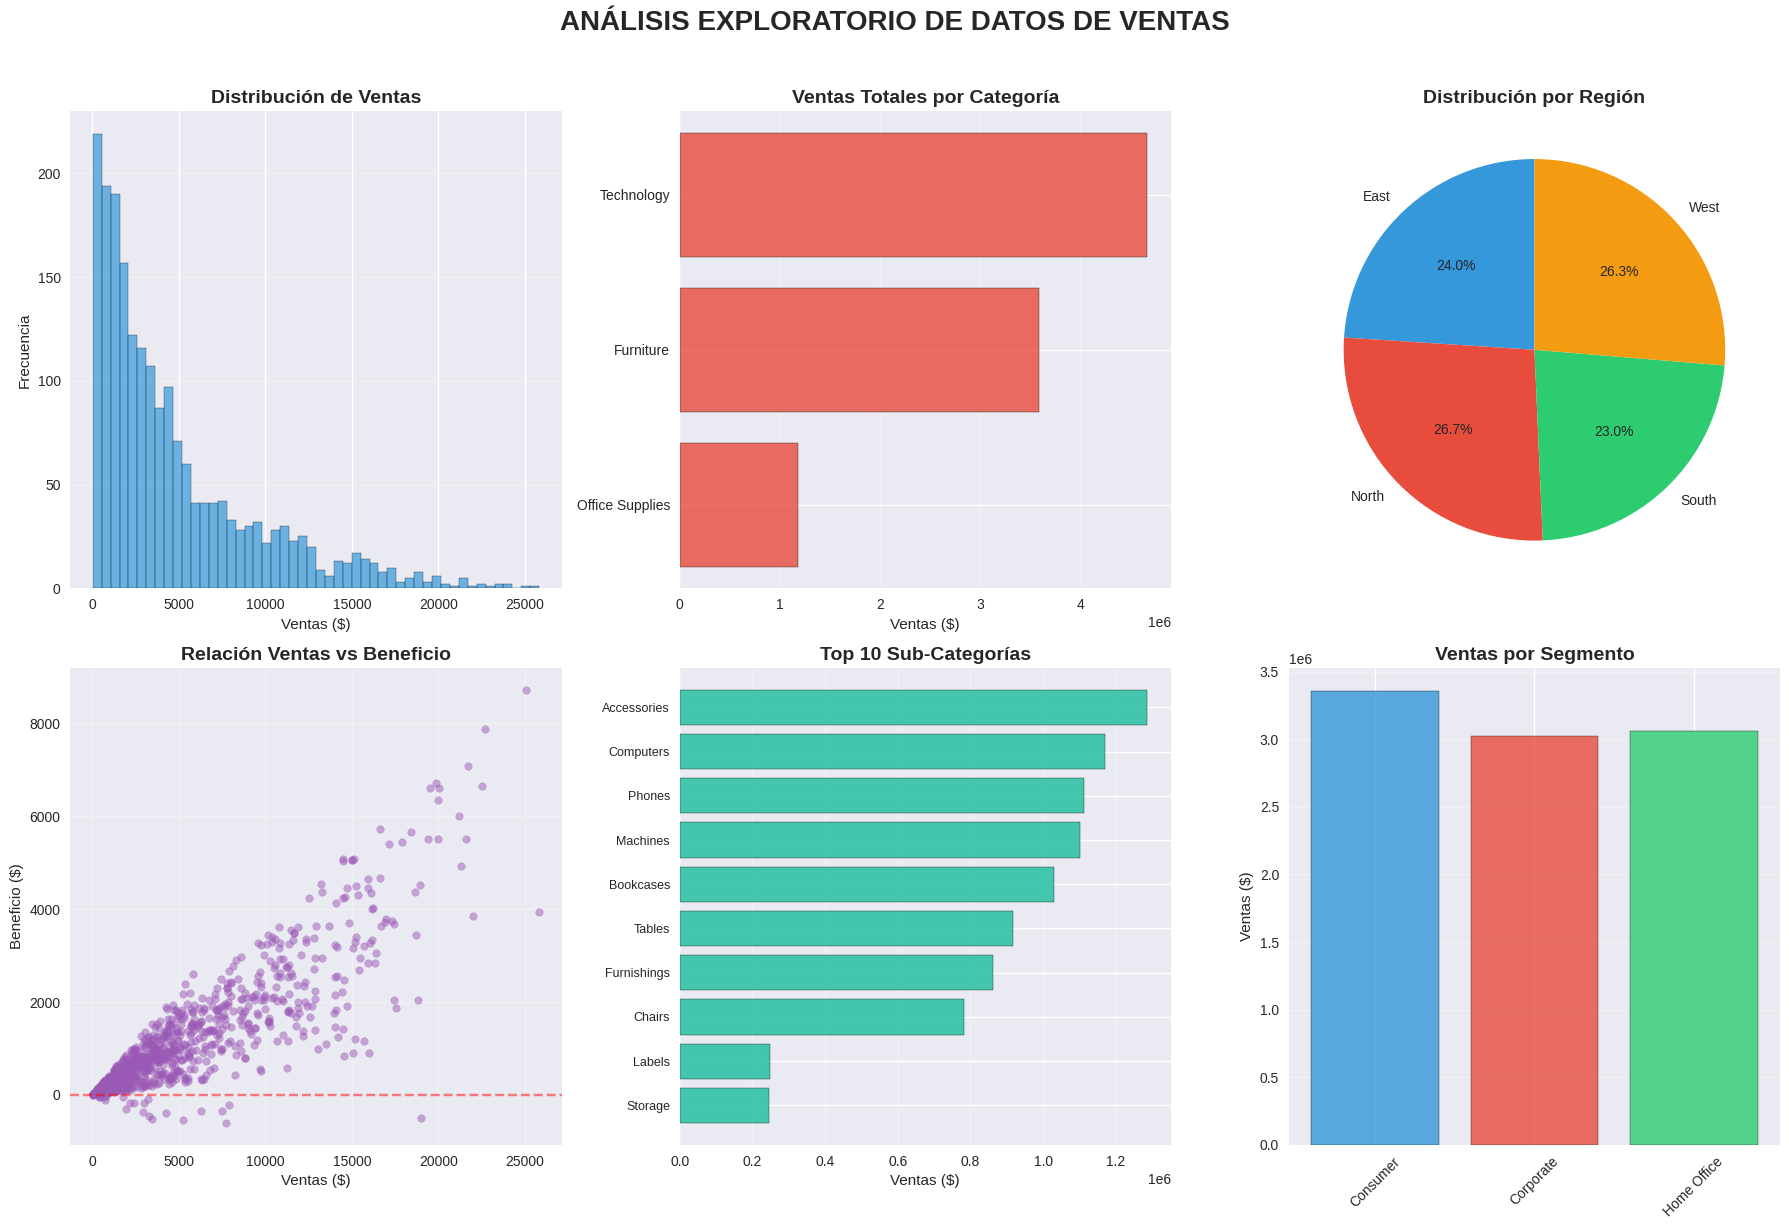

 Visualizaciones generadas
 TIP: Haz clic derecho en la imagen → 'Guardar imagen' para tu PDF


In [9]:
print("\n GENERANDO VISUALIZACIONES")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('ANÁLISIS EXPLORATORIO DE DATOS DE VENTAS',
             fontsize=20, fontweight='bold', y=1.02)

# Distribución de Ventas
axes[0, 0].hist(df['Sales'], bins=50, edgecolor='black', alpha=0.7, color='#3498db')
axes[0, 0].set_title('Distribución de Ventas', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Ventas ($)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

# Ventas por Categoría
ventas_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
axes[0, 1].barh(ventas_cat.index, ventas_cat.values, color='#e74c3c', edgecolor='black', alpha=0.8)
axes[0, 1].set_title('Ventas Totales por Categoría', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Ventas ($)', fontsize=11)
axes[0, 1].grid(axis='x', alpha=0.3)

# Ventas por Región
ventas_region = df.groupby('Region')['Sales'].sum()
colors_pie = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
axes[0, 2].pie(ventas_region, labels=ventas_region.index, autopct='%1.1f%%',
               startangle=90, colors=colors_pie)
axes[0, 2].set_title('Distribución por Región', fontsize=14, fontweight='bold')

# Ventas vs Beneficio
sample = df.sample(min(1000, len(df)))
axes[1, 0].scatter(sample['Sales'], sample['Profit'], alpha=0.5, color='#9b59b6', s=30)
axes[1, 0].set_title('Relación Ventas vs Beneficio', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Ventas ($)', fontsize=11)
axes[1, 0].set_ylabel('Beneficio ($)', fontsize=11)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].grid(True, alpha=0.3)

#  Top 10 Sub-Categorías
top_subcat = df.groupby('Sub-Category')['Sales'].sum().nlargest(10).sort_values()
axes[1, 1].barh(range(len(top_subcat)), top_subcat.values, color='#1abc9c', edgecolor='black', alpha=0.8)
axes[1, 1].set_yticks(range(len(top_subcat)))
axes[1, 1].set_yticklabels(top_subcat.index, fontsize=9)
axes[1, 1].set_title('Top 10 Sub-Categorías', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Ventas ($)', fontsize=11)
axes[1, 1].grid(axis='x', alpha=0.3)

# Ventas por Segmento
ventas_segmento = df.groupby('Segment')['Sales'].sum()
axes[1, 2].bar(ventas_segmento.index, ventas_segmento.values,
               color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.8)
axes[1, 2].set_title('Ventas por Segmento', fontsize=14, fontweight='bold')
axes[1, 2].set_ylabel('Ventas ($)', fontsize=11)
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualizaciones generadas")
print(" TIP: Haz clic derecho en la imagen → 'Guardar imagen' para tu PDF")

In [10]:
print("\n GRÁFICOS INTERACTIVOS")
print("="*60)

# Evolución Temporal
df_temporal = df.copy()
df_temporal['Mes'] = df_temporal['Order Date'].dt.to_period('M').astype(str)
ventas_mensuales = df_temporal.groupby('Mes')['Sales'].sum().reset_index()

fig1 = px.line(ventas_mensuales, x='Mes', y='Sales',
              title=' Evolución Temporal de Ventas',
              labels={'Mes': 'Mes', 'Sales': 'Ventas ($)'},
              markers=True)
fig1.update_traces(line_color='#3498db', line_width=3, marker=dict(size=8))
fig1.update_layout(height=500, hovermode='x unified')
fig1.show()

top_productos = df.groupby('Product Name')['Sales'].sum().nlargest(15).reset_index()

fig2 = px.bar(top_productos, x='Sales', y='Product Name',
             title=' Top 15 Productos por Ventas',
             labels={'Sales': 'Ventas ($)', 'Product Name': 'Producto'},
             orientation='h',
             color='Sales',
             color_continuous_scale='Viridis')
fig2.update_layout(height=600, showlegend=False)
fig2.show()

ventas_seg_cat = df.groupby(['Segment', 'Category'])['Sales'].sum().reset_index()

fig3 = px.sunburst(ventas_seg_cat, path=['Segment', 'Category'], values='Sales',
                   title=' Ventas por Segmento y Categoría',
                   color='Sales',
                   color_continuous_scale='RdYlGn')
fig3.update_layout(height=600)
fig3.show()

print(" Gráficos interactivos generados")
print(" TIP: Puedes hacer zoom, hover y explorar los gráficos")


 GRÁFICOS INTERACTIVOS


 Gráficos interactivos generados
 TIP: Puedes hacer zoom, hover y explorar los gráficos



 ANÁLISIS DE CORRELACIÓN


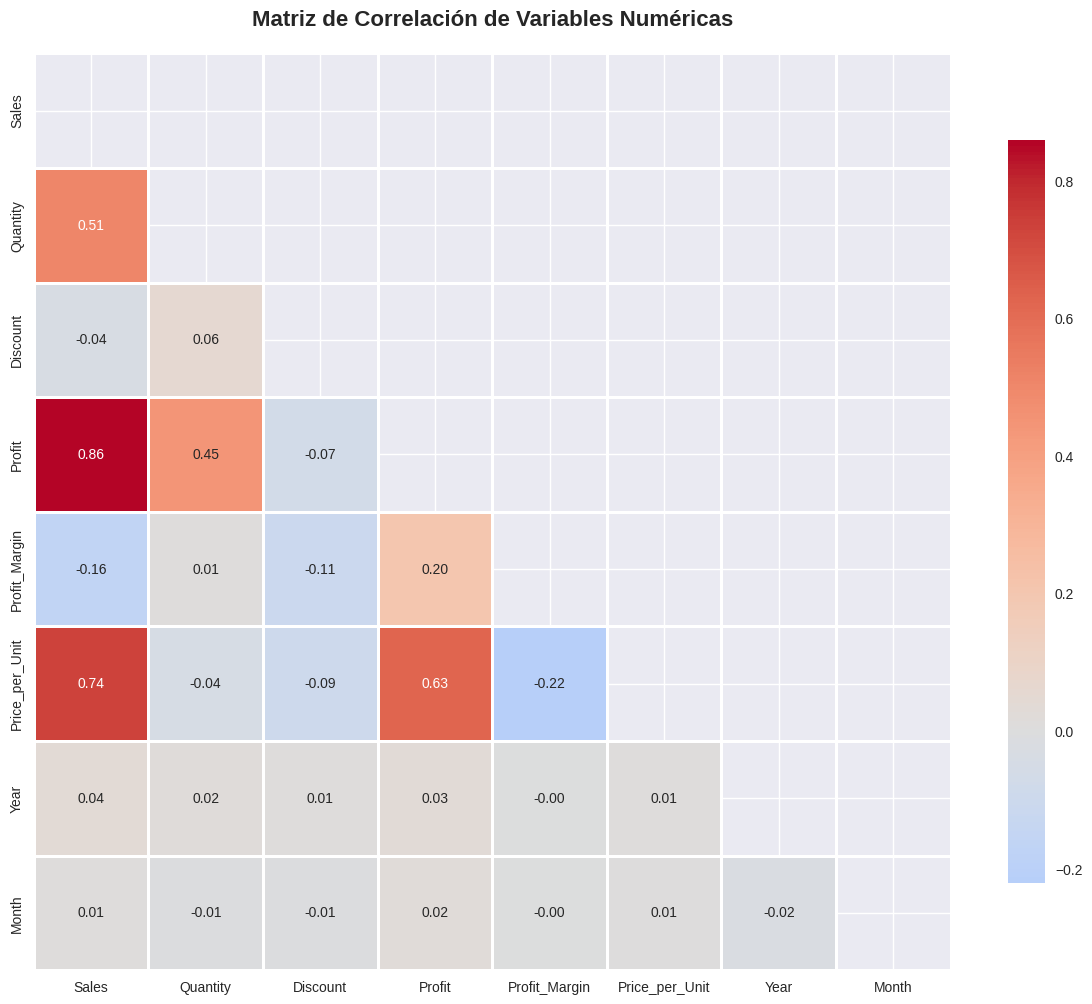


 Correlaciones más fuertes:
  1. Sales ↔ Profit: 0.859
  2. Sales ↔ Price_per_Unit: 0.736
  3. Profit ↔ Price_per_Unit: 0.630
  4. Sales ↔ Quantity: 0.506
  5. Quantity ↔ Profit: 0.447


In [11]:
print("\n ANÁLISIS DE CORRELACIÓN")
print("="*60)

columnas_correlacion = ['Sales', 'Quantity', 'Discount', 'Profit',
                        'Profit_Margin', 'Price_per_Unit', 'Year', 'Month']
columnas_correlacion = [col for col in columnas_correlacion if col in df.columns]

correlacion = df[columnas_correlacion].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlacion, dtype=bool))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, fmt='.2f', cbar_kws={"shrink": 0.8},
            mask=mask)
plt.title('Matriz de Correlación de Variables Numéricas',
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n Correlaciones más fuertes:")
# Obtener pares de correlación (excluyendo diagonal)
corr_pairs = []
for i in range(len(correlacion.columns)):
    for j in range(i+1, len(correlacion.columns)):
        corr_pairs.append((
            correlacion.columns[i],
            correlacion.columns[j],
            correlacion.iloc[i, j]
        ))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

#top 5
for i, (var1, var2, corr) in enumerate(corr_pairs[:5], 1):
    print(f"  {i}. {var1} ↔ {var2}: {corr:.3f}")

In [12]:
print("\n PREPARACIÓN PARA MACHINE LEARNING")
print("="*60)

df_model = df.copy()

print("\n🔧 Codificando variables categóricas...")
label_encoders = {}
columnas_cat = ['Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']

for col in columnas_cat:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col + '_encoded'] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le

print(f"    {len(label_encoders)} variables codificadas")

features_ml = [col for col in df_model.columns if col.endswith('_encoded')] + \
              ['Quantity', 'Discount', 'Year', 'Month', 'Quarter', 'Day_of_Week']

print(f"\n Features seleccionadas ({len(features_ml)}):")
for i, feat in enumerate(features_ml, 1):
    print(f"   {i}. {feat}")

print("\n Datos preparados para modelado")


 PREPARACIÓN PARA MACHINE LEARNING

🔧 Codificando variables categóricas...
    5 variables codificadas

 Features seleccionadas (11):
   1. Category_encoded
   2. Sub-Category_encoded
   3. Region_encoded
   4. Segment_encoded
   5. Ship Mode_encoded
   6. Quantity
   7. Discount
   8. Year
   9. Month
   10. Quarter
   11. Day_of_Week

 Datos preparados para modelado



 MODELO 1: REGRESIÓN - PREDICCIÓN DE VENTAS

 Entrenamiento: 1600 registros
 Prueba: 400 registros

 Entrenando modelos de regresión...

  ⚙️  Regresión Lineal... ✓
       R² = 0.2867 | RMSE = $4,106.95 | MAE = $3,129.37
  ⚙️  Árbol de Decisión... ✓
       R² = 0.2949 | RMSE = $4,083.34 | MAE = $2,625.33
  ⚙️  KNN... ✓
       R² = 0.2491 | RMSE = $4,213.96 | MAE = $2,961.23
  ⚙️  Random Forest... ✓
       R² = 0.5599 | RMSE = $3,225.91 | MAE = $2,179.15

 MEJOR MODELO: Random Forest
    R² Score: 0.5599
    RMSE: $3,225.91
    MAE: $2,179.15


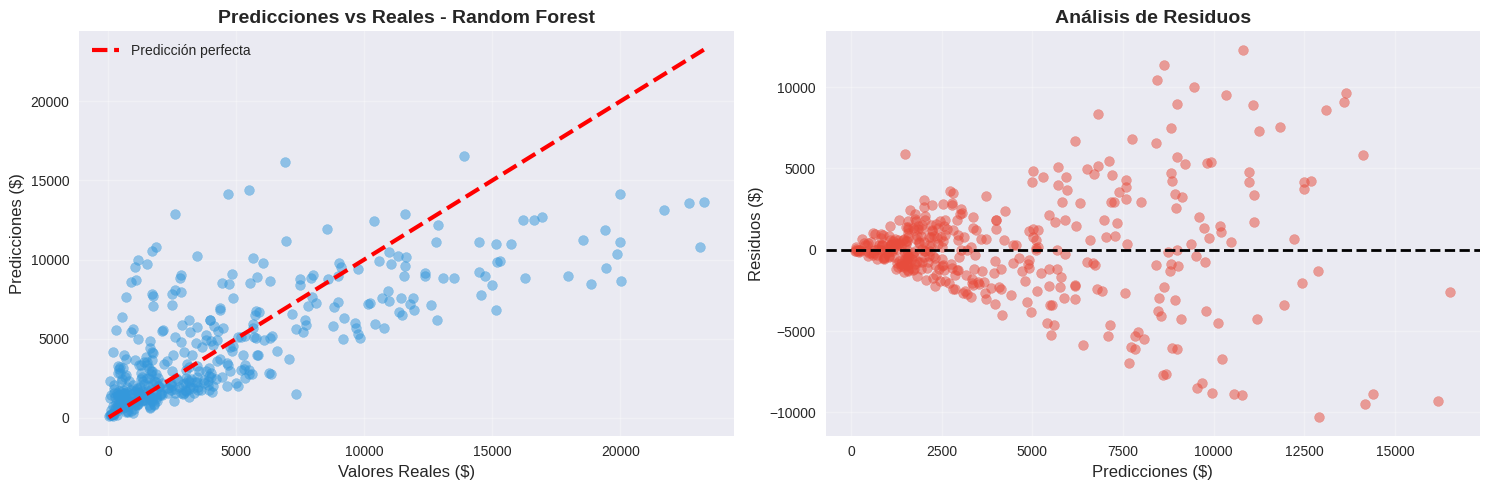


 Modelo de regresión completado


In [13]:
print("\n" + "="*60)
print(" MODELO 1: REGRESIÓN - PREDICCIÓN DE VENTAS")
print("="*60)

# Preparar datos
X_reg = df_model[features_ml].fillna(0)
y_reg = df_model['Sales']

# División
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Escalar
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"\n Entrenamiento: {X_train_reg.shape[0]} registros")
print(f" Prueba: {X_test_reg.shape[0]} registros")

modelos_reg = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42, max_depth=10),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
}

print("\n Entrenando modelos de regresión...\n")

resultados_reg = {}
for nombre, modelo in modelos_reg.items():
    print(f"  ⚙️  {nombre}...", end='')

    modelo.fit(X_train_reg_scaled, y_train_reg)
    y_pred_test = modelo.predict(X_test_reg_scaled)

    r2 = r2_score(y_test_reg, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
    mae = mean_absolute_error(y_test_reg, y_pred_test)

    resultados_reg[nombre] = {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'modelo': modelo}

    print(f" ✓")
    print(f"       R² = {r2:.4f} | RMSE = ${rmse:,.2f} | MAE = ${mae:,.2f}")

mejor_reg = max(resultados_reg.items(), key=lambda x: x[1]['R2'])
print(f"\n MEJOR MODELO: {mejor_reg[0]}")
print(f"    R² Score: {mejor_reg[1]['R2']:.4f}")
print(f"    RMSE: ${mejor_reg[1]['RMSE']:,.2f}")
print(f"    MAE: ${mejor_reg[1]['MAE']:,.2f}")

mejor_modelo_reg = mejor_reg[1]['modelo']
y_pred_mejor = mejor_modelo_reg.predict(X_test_reg_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_test_reg, y_pred_mejor, alpha=0.5, s=50, color='#3498db')
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()],
             'r--', lw=3, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales ($)', fontsize=12)
axes[0].set_ylabel('Predicciones ($)', fontsize=12)
axes[0].set_title(f'Predicciones vs Reales - {mejor_reg[0]}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuos = y_test_reg - y_pred_mejor
axes[1].scatter(y_pred_mejor, residuos, alpha=0.5, s=50, color='#e74c3c')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Predicciones ($)', fontsize=12)
axes[1].set_ylabel('Residuos ($)', fontsize=12)
axes[1].set_title('Análisis de Residuos', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Modelo de regresión completado")


 MODELO 2: CLASIFICACIÓN - CLIENTES RENTABLES

 Distribución de clases:
   Rentables: 1961 (98.0%)
   No Rentables: 39 (1.9%)

 Entrenando modelos de clasificación...

  ⚙️  Regresión Logística... ✓
       Accuracy = 0.9825 (98.25%)
  ⚙️  Árbol de Decisión... ✓
       Accuracy = 0.9800 (98.00%)
  ⚙️  KNN... ✓
       Accuracy = 0.9800 (98.00%)
  ⚙️  Random Forest... ✓
       Accuracy = 0.9800 (98.00%)

 MEJOR MODELO: Regresión Logística
    Accuracy: 0.9825 (98.25%)

 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

 No Rentable       0.67      0.25      0.36         8
    Rentable       0.98      1.00      0.99       392

    accuracy                           0.98       400
   macro avg       0.83      0.62      0.68       400
weighted avg       0.98      0.98      0.98       400



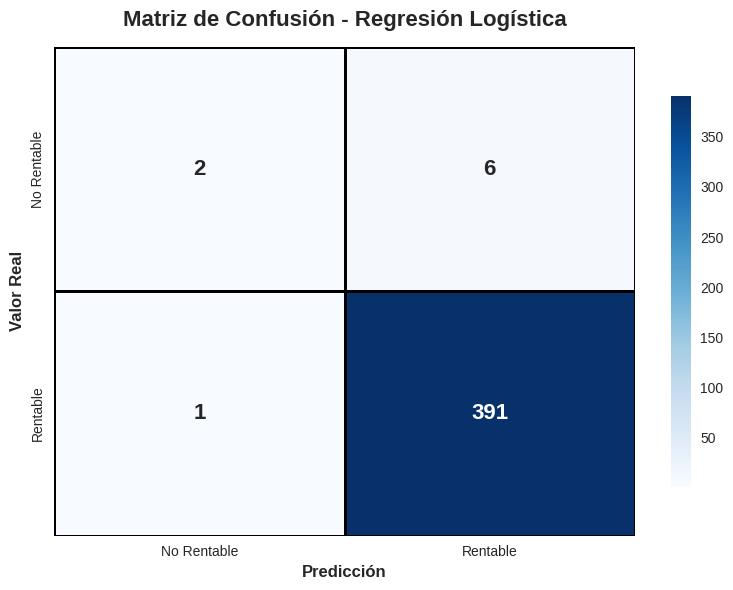


 Modelo de clasificación completado


In [14]:
print("\n" + "="*60)
print(" MODELO 2: CLASIFICACIÓN - CLIENTES RENTABLES")
print("="*60)

X_clf = df_model[features_ml].fillna(0)
y_clf = df_model['Cliente_Rentable']

print(f"\n Distribución de clases:")
print(f"   Rentables: {(y_clf==1).sum()} ({(y_clf==1).sum()/len(y_clf)*100:.1f}%)")
print(f"   No Rentables: {(y_clf==0).sum()} ({(y_clf==0).sum()/len(y_clf)*100:.1f}%)")

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

modelos_clf = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42, max_depth=10),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, n_jobs=-1)
}

print("\n Entrenando modelos de clasificación...\n")

resultados_clf = {}
for nombre, modelo in modelos_clf.items():
    print(f"  ⚙️  {nombre}...", end='')

    modelo.fit(X_train_clf_scaled, y_train_clf)
    y_pred_test = modelo.predict(X_test_clf_scaled)

    acc = accuracy_score(y_test_clf, y_pred_test)

    resultados_clf[nombre] = {'Accuracy': acc, 'modelo': modelo}

    print(f" ✓")
    print(f"       Accuracy = {acc:.4f} ({acc*100:.2f}%)")

mejor_clf = max(resultados_clf.items(), key=lambda x: x[1]['Accuracy'])
print(f"\n MEJOR MODELO: {mejor_clf[0]}")
print(f"    Accuracy: {mejor_clf[1]['Accuracy']:.4f} ({mejor_clf[1]['Accuracy']*100:.2f}%)")

mejor_modelo_clf = mejor_clf[1]['modelo']
y_pred_final = mejor_modelo_clf.predict(X_test_clf_scaled)

print("\n REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test_clf, y_pred_final,
                            target_names=['No Rentable', 'Rentable']))

cm = confusion_matrix(y_test_clf, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Rentable', 'Rentable'],
            yticklabels=['No Rentable', 'Rentable'],
            cbar_kws={"shrink": 0.8}, linewidths=2, linecolor='black',
            annot_kws={"size": 16, "weight": "bold"})
plt.title(f'Matriz de Confusión - {mejor_clf[0]}', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Predicción', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Modelo de clasificación completado")


 RESUMEN FINAL DEL PROYECTO

 MODELOS DE REGRESIÓN (Predicción de Ventas):
------------------------------------------------------------

Regresión Lineal:
  R² Score: 0.2867
  RMSE: $4,106.95
  MAE: $3,129.37

Árbol de Decisión:
  R² Score: 0.2949
  RMSE: $4,083.34
  MAE: $2,625.33

KNN:
  R² Score: 0.2491
  RMSE: $4,213.96
  MAE: $2,961.23

Random Forest:
  R² Score: 0.5599
  RMSE: $3,225.91
  MAE: $2,179.15

 Mejor modelo de regresión: Random Forest
   → Explica el 55.99% de la variabilidad en ventas

------------------------------------------------------------
 MODELOS DE CLASIFICACIÓN (Clientes Rentables):
------------------------------------------------------------

Regresión Logística:
  Accuracy: 0.9825 (98.25%)

Árbol de Decisión:
  Accuracy: 0.9800 (98.00%)

KNN:
  Accuracy: 0.9800 (98.00%)

Random Forest:
  Accuracy: 0.9800 (98.00%)

 Mejor modelo de clasificación: Regresión Logística
   → Accuracy de 98.25%


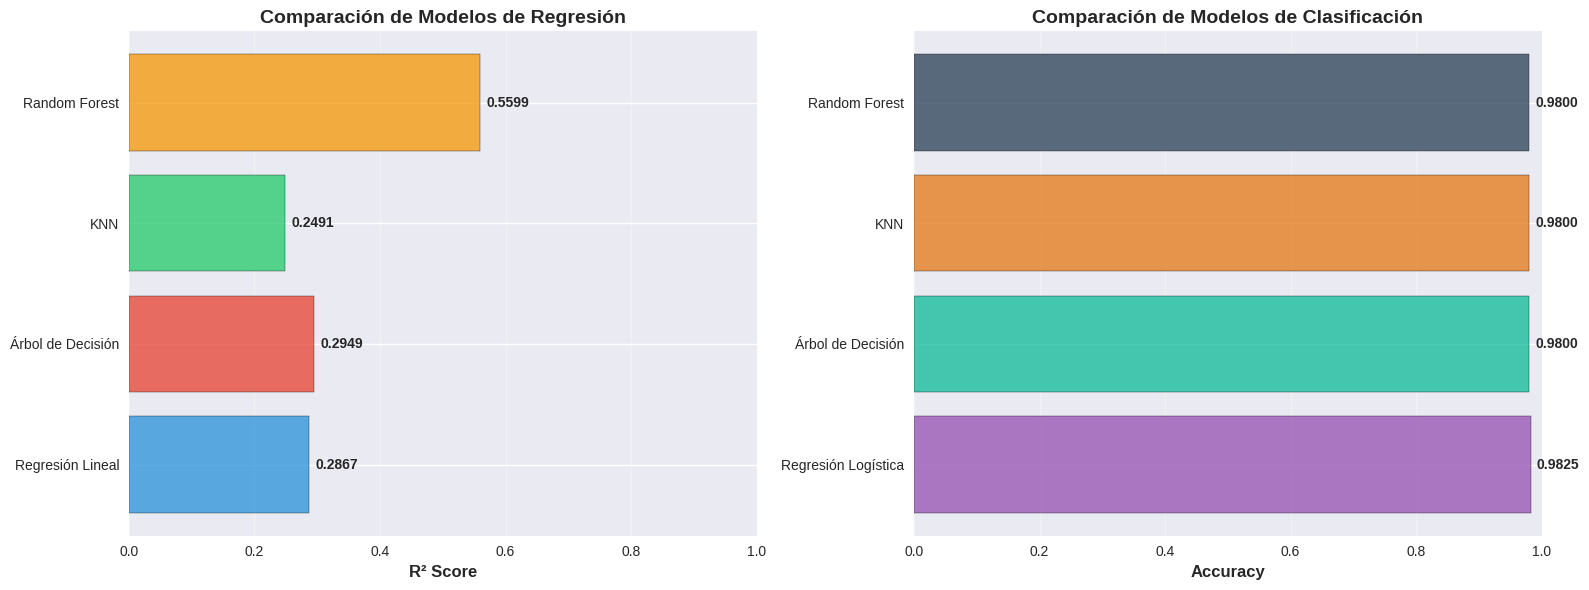


 Análisis completo finalizado


In [15]:
print("\n" + "="*60)
print(" RESUMEN FINAL DEL PROYECTO")
print("="*60)

print("\n MODELOS DE REGRESIÓN (Predicción de Ventas):")
print("-" * 60)
for nombre, metricas in resultados_reg.items():
    print(f"\n{nombre}:")
    print(f"  R² Score: {metricas['R2']:.4f}")
    print(f"  RMSE: ${metricas['RMSE']:,.2f}")
    print(f"  MAE: ${metricas['MAE']:,.2f}")

print(f"\n Mejor modelo de regresión: {mejor_reg[0]}")
print(f"   → Explica el {mejor_reg[1]['R2']*100:.2f}% de la variabilidad en ventas")

print("\n" + "-"*60)
print(" MODELOS DE CLASIFICACIÓN (Clientes Rentables):")
print("-" * 60)
for nombre, metricas in resultados_clf.items():
    print(f"\n{nombre}:")
    print(f"  Accuracy: {metricas['Accuracy']:.4f} ({metricas['Accuracy']*100:.2f}%)")

print(f"\n Mejor modelo de clasificación: {mejor_clf[0]}")
print(f"   → Accuracy de {mejor_clf[1]['Accuracy']*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nombres_reg = list(resultados_reg.keys())
r2_scores = [resultados_reg[n]['R2'] for n in nombres_reg]

axes[0].barh(nombres_reg, r2_scores, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
             edgecolor='black', alpha=0.8)
axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Comparación de Modelos de Regresión', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim([0, 1])

for i, (nombre, score) in enumerate(zip(nombres_reg, r2_scores)):
    axes[0].text(score + 0.01, i, f'{score:.4f}', va='center', fontweight='bold')

nombres_clf = list(resultados_clf.keys())
acc_scores = [resultados_clf[n]['Accuracy'] for n in nombres_clf]

axes[1].barh(nombres_clf, acc_scores, color=['#9b59b6', '#1abc9c', '#e67e22', '#34495e'],
             edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].set_title('Comparación de Modelos de Clasificación', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].set_xlim([0, 1])

for i, (nombre, score) in enumerate(zip(nombres_clf, acc_scores)):
    axes[1].text(score + 0.01, i, f'{score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Análisis completo finalizado")